# Isostatic topography

In this notebook, I take a 2-d domain outputs and compute horizontally distributed (along X) column-balanced topography.

# Read in a vtk file format

This comes from a previous computation of subduction-collision model. The domain is of size of 5500 km, 2000 km.
There are 4 regions distributed horizontally:
* 0 - 1000 km: A with continent, 20 km upper crust, 20 km lower crust
* 1000 - 1500 km: A passive margin
* 1500 - 2500 km: An oceanic basin, 2 km sediments, 4 km MORB, 4 km gabbro
* 2500 - 5500 km: Another continent

In [1]:
import vtk
from vtk.util.numpy_support import vtk_to_numpy
import os, sys
import time
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import matplotlib.pyplot as plt

# Include this pakage
HaMaGeoLib_DIR = "/home/lochy/ASPECT_PROJECT/HaMaGeoLib"
if os.path.abspath(HaMaGeoLib_DIR) not in sys.path:
    sys.path.append(os.path.abspath(HaMaGeoLib_DIR))

from hamageolib.utils.vtk_utilities import calculate_resolution

# Options
# case-dir: set the case directory
# do_resolution_calculation: calculate resolution. This takes time (~mins)
case_dir = "/mnt/lochy/ASPECT_DATA/Collision0/collision_setup27/C_ar4_WLM_WLF5.0e-02_SA50.0_FS"

vtu_step = 0

do_resolution_calculation = False

# Read in the output of timestep 0
pvtu_file = os.path.join(case_dir, "output", "solution", "solution-%05d.pvtu" % vtu_step)
assert(os.path.isfile(pvtu_file))

# Read the pvtu file
start = time.time()

reader = vtk.vtkXMLPUnstructuredGridReader()
reader.SetFileName(pvtu_file)
reader.Update()

end = time.time()
print("Initiating reader takes %.2e s" % (end - start))
start = end

# Get the output data from the reader
grid = reader.GetOutput()  # Access the unstructured grid
data_set = reader.GetOutputAsDataSet()  # Access the dataset representation
points = grid.GetPoints()  # Extract the points (coordinates)
cells = grid.GetCells()  # Extract the cell connectivity information
point_data = data_set.GetPointData()  # Access point-wise data

n_points = grid.GetNumberOfPoints() # Number of points and cells
n_cells = grid.GetNumberOfCells()

end = time.time()
print("Reading files takes %.2e s" % (end - start))
print(f"\tNumber of points: {n_points}")
print(f"\tNumber of cells: {n_cells}")
print("\tAvailable point data fields:")
for i in range(point_data.GetNumberOfArrays()):
    # Field names in point data
    name = point_data.GetArrayName(i)
    print(f"\t  - {name}")
start = end

# Convert data to numpy array
# Get coordinates (points)
# Get field "T"

vtk_points = grid.GetPoints().GetData()
points_np = vtk_to_numpy(vtk_points)  # Shape: (n_points, 3)
points_2d = points_np[:, :2]  # Use only the first two columns for 2D coordinates

# Initialize dictionary for interpolators
interpolators = {}

# Loop over all arrays in point data
num_arrays = point_data.GetNumberOfArrays()
for i in range(num_arrays):
    array_name = point_data.GetArrayName(i)
    vtk_array = point_data.GetArray(i)
    
    if vtk_array is None:
        print(f"Warning: Array {array_name} is None, skipping.")
        continue
    
    # Convert VTK array to NumPy
    np_array = vtk_to_numpy(vtk_array)
    
    # Create interpolator and add to dict
    interpolators[array_name] = LinearNDInterpolator(points_2d, np_array, fill_value=np.nan)
end = time.time()
print("Construct linear ND interpolator takes %.2e s" % (end - start))
start = end

# Calculate resolution for each cell or point in the grid
if do_resolution_calculation:
    resolution_np = calculate_resolution(grid)  # Custom function (not defined here)

    # Create interpolators for temperature, pressure, and resolution
    interpolators["resolution"] = LinearNDInterpolator(points_2d, resolution_np)  # Interpolator for resolution

    end = time.time()
    print("Calculating resolution takes %.2e s" % (end - start))
    start = end


Initiating reader takes 7.86e-01 s
Reading files takes 2.16e-04 s
	Number of points: 531000
	Number of cells: 236000
	Available point data fields:
	  - velocity
	  - principal_stress_direction_1
	  - principal_stress_direction_2
	  - p
	  - T
	  - gabbro
	  - MORB
	  - sediment
	  - harzburgite
	  - crust_upper
	  - crust_lower
	  - density
	  - viscosity
	  - strain_rate
	  - current_cohesions
	  - current_friction_angles
	  - current_yield_stresses
	  - plastic_yielding
	  - prescribed_temperature
	  - stress_second_invariant
	  - depth
	  - heat_flux_map
	  - nonadiabatic_pressure
	  - principal_stress_1
	  - principal_stress_2
Construct linear ND interpolator takes 1.11e+02 s


# Options for isotatic topography

* balanced_depth (m) - density to use to compute the topography based on column mass anomaly
* cutoff_wavelength (m) - lowest wavelength for a low-pass FFT filter on the column mass anomaly

The block below creates a regular mesh for interpolation and integration. The resolution of the mesh depending on the parametes

    resolution_X = 1e3
    resolution_Y = 1e3

In [ ]:
# ------------------------------------------------------------------
# Additional options
# X, Ymax - length dimension of the domain
# balanced_depth - Mass balanced below this point. This dictates
# density to use to compute the topography based on column mass anomaly
# cutoff_wavelength - lowest wavelength for a low-pass FFT filter on the
# column mass anomaly
# ------------------------------------------------------------------
Xmax = 5500e3
Ymax = 2000e3

balanced_depth = 500e3
cutoff_wavelength = 500e3 

# ------------------------------------------------------------------
# Create a regular sampling mesh
# ------------------------------------------------------------------
resolution_X = 1e3
resolution_Y = 1e3

# Coordinates
Xp = np.arange(0.0, Xmax, resolution_X)
Yp = np.arange(0.0, Ymax, resolution_Y)

nX = Xp.size
nY = Yp.size

# Grid
XX, YY = np.meshgrid(Xp, Yp, indexing="xy")

# Flattened coordinates for interpolation
query_points = np.column_stack((XX.ravel(), YY.ravel()))

# Area represented by each sample
dA = resolution_X * resolution_Y
total_area = dA * nX * nY

# Compute the id of point along the y axis closest to the balanced depth 
balanced_idx = np.argmin(np.abs(Yp - (Ymax - balanced_depth)))

print("Mesh information:")
print(f"\tnX = {nX}")
print(f"\tnY = {nY}")
print(f"\tnumber of query points = {query_points.shape[0]}")
print(f"\ttotal area = {total_area/1e6:.2f} km²")

1500
Mesh information:
	nX = 5500
	nY = 2000
	number of query points = 11000000
	total area = 11000000.00 km²


# Interpolate and integrate in the mesh

## Density and the sum of mass 

The density field is interpolated at every point.
The sum of mass for the mesh is computed by integration in the whole domain.

In [3]:
# Interpolate density onto the regular mesh
density = interpolators["density"](query_points)

# Convert from (nX*nY,) to (nY, nX)
density = density.reshape(nY, nX)

# Integrate density over the domain
valid_mask = np.isfinite(density)

total_mass = np.sum(density[valid_mask] * dA)

average_column_mass = total_mass / Xmax

print(f"Total mass per out-of-plane length = {total_mass:.6e} kg/m")
print(f"Average column mass = {average_column_mass:.6e} kg/m²")

Total mass per out-of-plane length = 4.812868e+16 kg/m
Average column mass = 8.750668e+09 kg/m²


## A column mass for each X

The width of the column is assumed to be topography along the X axis.

An accumulated profile is also computed for each column from the top downward.

In [4]:
# column_mass sums the mass below each column
column_mass = np.zeros(nX)

for i in range(nX):
    valid = np.isfinite(density[:, i])
    column_mass[i] = np.sum(density[valid, i]) * dA

# Accumulate from the top downward
# At the top: one grid-cell contribution, not exactly zero
# by accumulated_column_mass[-1, :]
# At the bottom: full column mass
# by accumulated_column_mass[0, :], and this should equal to
# the column mass
density_valid = np.nan_to_num(density, nan=0.0)

accumulated_column_mass = (
    np.cumsum(density_valid[::-1, :], axis=0)[::-1, :] * dA
)

assert np.allclose(
    accumulated_column_mass[0, :],
    column_mass,
)

print(accumulated_column_mass.shape)  # (nY, nX)

(2000, 5500)


## Column mass anomaly

A column mass anomaly is computed by deviation from the average value, at every X.

In [ ]:
# Derive the column mass anomaly and apply a low-pass filter

column_mass_anomaly = column_mass - average_column_mass * resolution_X

dx = resolution_X
N = column_mass_anomaly.size

# FFT
fft = np.fft.rfft(column_mass_anomaly)

# Corresponding wavenumbers (cycles/m)
freq = np.fft.rfftfreq(N, d=dx)

# Convert cutoff wavelength to cutoff frequency
cutoff_frequency = 1.0 / cutoff_wavelength

# Low-pass filter
filter = freq <= cutoff_frequency

fft_filtered = fft * filter

# Back to physical space
column_mass_anomaly_filtered = np.fft.irfft(
    fft_filtered,
    n=N
)

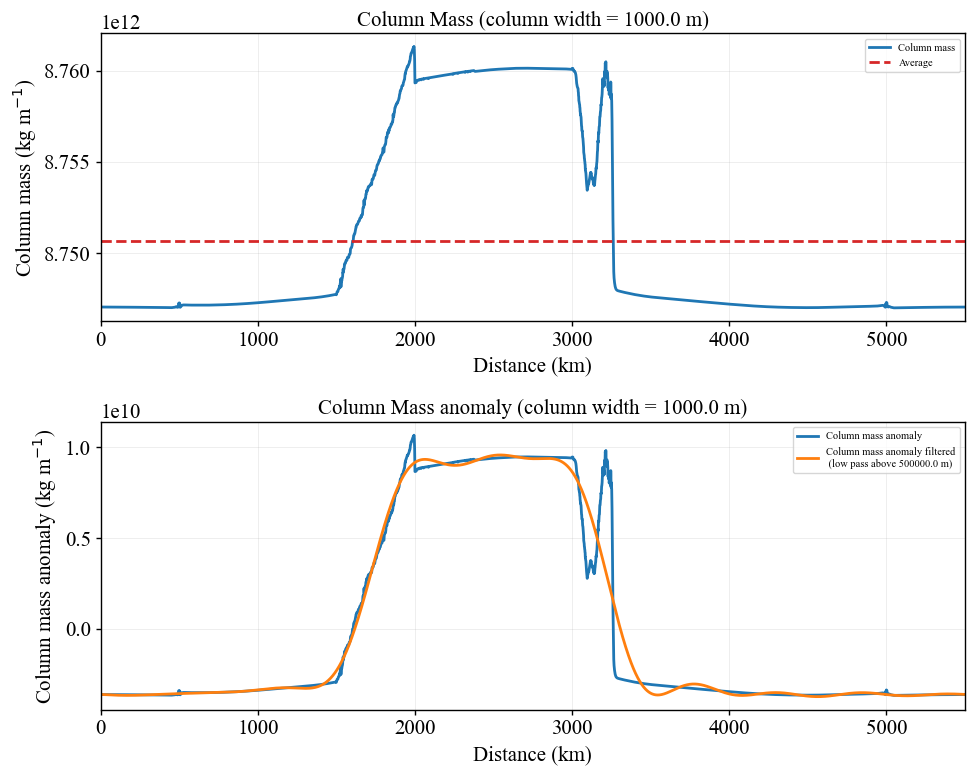

In [16]:
# Plot the mass in every column as well as
# the average value

from matplotlib import rcdefaults
from matplotlib.ticker import MultipleLocator
from matplotlib import gridspec
from cmcrameri import cm as ccm
import hamageolib.utils.plot_helper as plot_helper

# Retrieve the default color cycle
default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]

# Example usage
# Rule of thumbs:
# 1. Set the limit to something like 5.0, 10.0 or 50.0, 100.0 
# 2. Set five major ticks for each axis
scaling_factor = 1.0  # scale factor of plot
font_scaling_multiplier = 1.5 # extra scaling multiplier for font
legend_font_scaling_multiplier = 0.5
line_width_scaling_multiplier = 2.0 # extra scaling multiplier for lines

n_minor_ticks = 4  # number of minor ticks between two major ones

# scale the matplotlib params
plot_helper.scale_matplotlib_params(scaling_factor, font_scaling_multiplier=font_scaling_multiplier,\
                        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
                        line_width_scaling_multiplier=line_width_scaling_multiplier)

# Update font settings for compatibility with publishing tools like Illustrator.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig = plt.figure(tight_layout=True, figsize=(10, 8))
gs = gridspec.GridSpec(2, 1)

# plot the column mass
ax = fig.add_subplot(gs[0, 0])

ax.plot(
    Xp / 1e3,
    column_mass,
    color="C0",
    linewidth=2,
    label="Column mass"
)

ax.axhline(
    average_column_mass*1e3,
    color="C3",
    linestyle="--",
    linewidth=2,
    label="Average"
)

ax.set_xlabel("Distance (km)")
ax.set_ylabel(r"Column mass (kg m$^{-1}$)")
ax.set_title(f"Column Mass (column width = {resolution_X} m)")
ax.set_xlim(0, Xmax / 1e3)

ax.grid(True, alpha=0.3)
ax.legend()

for spine in ax.spines.values():
    # Adjust spine thickness for this plot
    spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)

# plot the column mass anomaly
ax1 = fig.add_subplot(gs[1, 0])

ax1.plot(
    Xp / 1e3,
    column_mass_anomaly,
    color=default_colors[0],
    linewidth=2,
    label="Column mass anomaly"
)

ax1.plot(
    Xp / 1e3,
    column_mass_anomaly_filtered,
    color=default_colors[1],
    linewidth=2,
    label="Column mass anomaly filtered\n (low pass above %.1f m)" % cutoff_wavelength
)

ax1.set_xlabel("Distance (km)")
ax1.set_ylabel(r"Column mass anomaly (kg m$^{-1}$)")
ax1.set_title(f"Column Mass anomaly (column width = {resolution_X} m)")
ax1.set_xlim(0, Xmax / 1e3)

ax1.grid(True, alpha=0.3)
ax1.legend()

for spine in ax1.spines.values():
    # Adjust spine thickness for this plot
    spine.set_linewidth(0.5 * scaling_factor * line_width_scaling_multiplier)

# Additional plot operations
plt.tight_layout()
plt.show()

# Reset rcParams to defaults
rcdefaults()

# Derive a mass-balanced depth for each column

If the mass in one column is small than the average, then it's extended using the density at the bottom.

Then the mass-balanced topography could be computed by:

    column_balance_topography = column_balance_depth - Ymax

At the end, plot both the balanced topography with X and query for a given X how this depth is reached.

In [35]:

target_mass = average_column_mass * resolution_X

# 
# column_balance_depth - numerically compute the depth of balanced mass
# column_balance_depth_bd - use the lowest point's density to calculate the balanced mass
# column_balance_depth_bd - use the lowest point's density to calculate the balanced mass from filtered anomaly
column_balance_depth = np.zeros(nX)
column_balance_depth_bd = np.zeros(nX)
column_balance_depth_filtered_bd = np.zeros(nX)

for i in range(nX):

    # reverse the column mass so index 0 is at the surface
    acc = accumulated_column_mass[:, i]   # shape (nY+1,)
    acc_reversed = acc[::-1]
    
    # compute the extra_depth to reach the balanced mass
    # based on the density of the deepest point
    remaining_mass = target_mass - acc_reversed[-1]

    rho_bottom = density[balanced_idx, i]

    if np.isfinite(rho_bottom) and rho_bottom > 0.0:
        extra_depth = remaining_mass / (rho_bottom * resolution_X)
    else:
        extra_depth = np.nan

    # numerically compute the depth of balanced mass
    reached = np.nonzero(acc_reversed >= target_mass)[0]

    if reached.size > 0:
        # First interface where target is reached
        k = reached[0]

        if k == 0:
            column_balance_depth[i] = 0.0
        else:
            # Mass just above and below the target
            m0 = acc_reversed[k-1]
            m1 = acc_reversed[k]

            # Linear interpolation within this layer
            frac = (target_mass - m0) / (m1 - m0)

            column_balance_depth[i] = (
                (k - 1 + frac) * resolution_Y
            )

    else:
        # Need to extrapolate below the bottom

        column_balance_depth[i] = Ymax + extra_depth

    # simply use the lowest point's density to calculate the balanced mass
    column_balance_depth_bd[i] = Ymax + extra_depth

    # simply use the lowest point's density to calculate the balanced mass with the filtered mass anomaly
    column_balance_depth_filtered_bd[i] = Ymax - column_mass_anomaly_filtered[i] / (rho_bottom * resolution_X)

column_balance_topography = column_balance_depth - Ymax
column_balance_topography_bd = column_balance_depth_bd - Ymax
column_balance_topography_filtered_bd = column_balance_depth_filtered_bd - Ymax

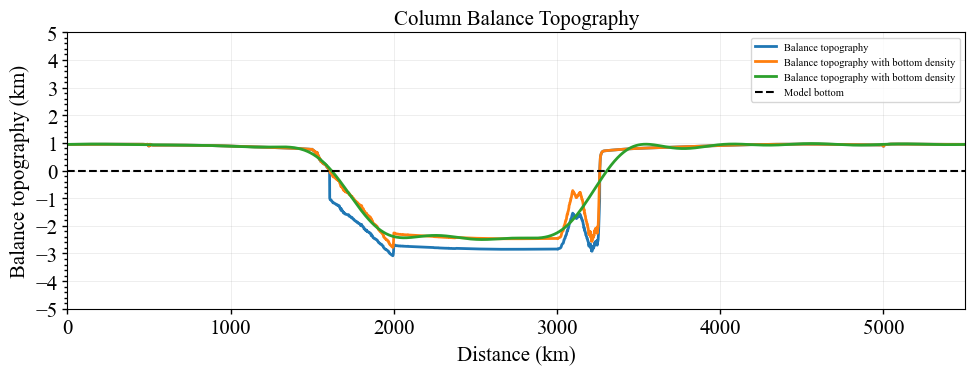

In [32]:
import matplotlib.pyplot as plt

# Retrieve the default color cycle
default_colors = [color['color'] for color in plt.rcParams['axes.prop_cycle']]

# Example usage
# Rule of thumbs:
# 1. Set the limit to something like 5.0, 10.0 or 50.0, 100.0 
# 2. Set five major ticks for each axis
scaling_factor = 1.0  # scale factor of plot
font_scaling_multiplier = 1.5 # extra scaling multiplier for font
legend_font_scaling_multiplier = 0.5
line_width_scaling_multiplier = 2.0 # extra scaling multiplier for lines

n_minor_ticks = 4  # number of minor ticks between two major ones

# scale the matplotlib params
plot_helper.scale_matplotlib_params(scaling_factor, font_scaling_multiplier=font_scaling_multiplier,\
                        legend_font_scaling_multiplier=legend_font_scaling_multiplier,
                        line_width_scaling_multiplier=line_width_scaling_multiplier)

# Update font settings for compatibility with publishing tools like Illustrator.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    Xp / 1e3,
    column_balance_topography / 1e3,
    color=default_colors[0],
    linewidth=2,
    label="Balance topography"
)

ax.plot(
    Xp / 1e3,
    column_balance_topography_bd / 1e3,
    color=default_colors[1],
    linewidth=2,
    label="Balance topography with bottom density"
)

ax.plot(
    Xp / 1e3,
    column_balance_topography_filtered_bd / 1e3,
    color=default_colors[2],
    linewidth=2,
    label="Balance topography with bottom density"
)

ax.axhline(
    0.0,
    color="k",
    linestyle="--",
    linewidth=1.5,
    label="Model bottom"
)

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Balance topography (km)")
ax.set_title("Column Balance Topography")

ax.set_xlim(0, Xmax / 1e3)

ax.set_ylim([-5, 5])
y_tick_interval = 1.0
ax.yaxis.set_major_locator(MultipleLocator(y_tick_interval))
ax.yaxis.set_minor_locator(MultipleLocator(y_tick_interval/(n_minor_ticks+1)))

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
    
# Reset rcParams to defaults
rcdefaults()

Selected column:
    index = 1000
    X = 1000.0 km


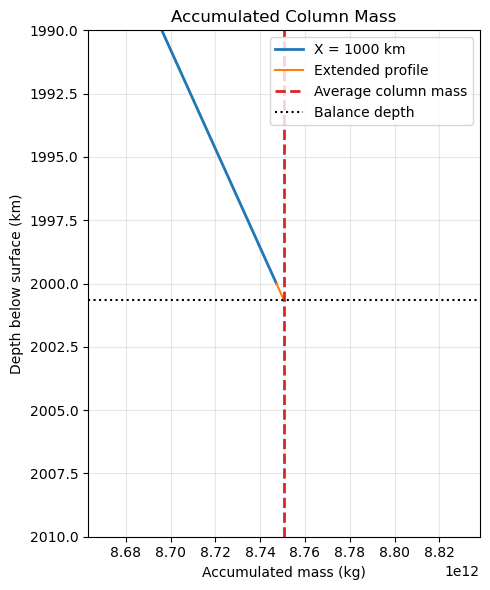

In [8]:
import matplotlib.pyplot as plt

# ---------------------------------------------
# Select a horizontal location
# ---------------------------------------------
x_query = 1000e3  # meters

# Find the closest sampled column
iX = np.argmin(np.abs(Xp - x_query))

print(f"Selected column:")
print(f"    index = {iX}")
print(f"    X = {Xp[iX]/1e3:.1f} km")

fig, ax = plt.subplots(figsize=(5, 6))

ax.plot(
    accumulated_column_mass[:, iX],
    (Ymax - Yp) / 1e3,
    linewidth=2,
    label=f"X = {Xp[iX]/1e3:.0f} km",
    color=default_colors[0]
)

if (column_balance_depth[iX] > Ymax):
    ax.plot([accumulated_column_mass[0, iX], target_mass], 
            [Ymax/1e3, column_balance_depth[iX]/1e3],
            color=default_colors[1],
            label="Extended profile")

# Target mass
target_mass = average_column_mass * resolution_X

ax.axvline(
    target_mass,
    color="C3",
    linestyle="--",
    linewidth=2,
    label="Average column mass"
)

# Plot the balance depth
ax.axhline(
    column_balance_depth[iX] / 1e3,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label="Balance depth"
)



ax.set_xlabel("Accumulated mass (kg)")
ax.set_xlim(0.99*target_mass, 1.01*target_mass)

ax.set_ylabel("Depth below surface (km)")
ax.set_ylim(Ymax/1e3-10, Ymax/1e3+10)

ax.set_title("Accumulated Column Mass")

# Make depth increase downward
ax.invert_yaxis()

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()